<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_4%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**4장. 모델 훈련**



*   여태까지는 모델을 블랙박스로 여기고 작동 방식에 대한 이해는 하지 않았음
*   그러나 작동 방식의 이해는 적절한 모델 선태그 훈련 알고리즘 최적화, 효율적인 하이퍼파라미터 설정에 큰 도움이 됨
*   선형회귀->다항회귀->로지스틱& 소프트맥스 회귀와 과대적합 탐지 및 방지를 위한 규제를 다룸


**4.1 선형 회귀**

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

*   y_hat: 예측치, 세타0:절편, 세타1,2,...n:기울기(회귀계수), x1,2,...,n: 변수의 수인 선형 결합으로 표현됨

$$\hat{y} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \boldsymbol{\theta}^T \mathbf{x}$$

*   위와 같이 벡터 형태로도 적을수 있음
*   세타^T: 파라미터 벡터(행벡터)/x벡터: 변수의 열벡터



**4.1.1 정규 방정식**
$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$


*   비용함수인 RMSE를 최소화하는 수학 공식이 있음
*   위와 같은 공식을 **정규방정식**이라고 함*4.1.1 정규 방정식**
$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$


*   비용함수인 RMSE를 최소화하는 수학 공식이 있음
*   위와 같은 공식을 **정규방정식**이라고 함
*   세타_hat은 비용함수를 최소화 하는 세타값
*   y는 타깃 벡터



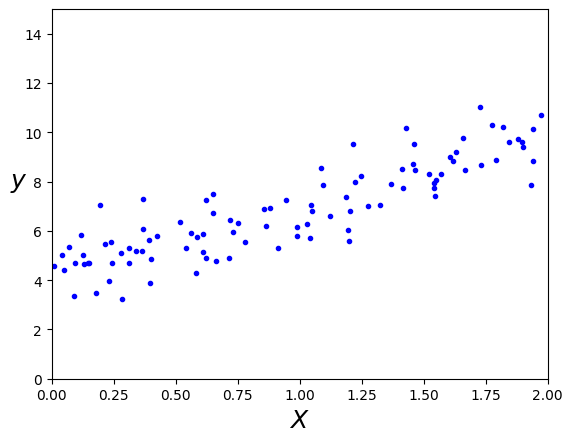

In [1]:
#랜덤 데이터 생성
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
m=100 #샘플 개수
X = 2*np.random.rand(m,1) # 열 벡터 np.random.randn(m,1)->0~1 사이에서 난수를 뽑아 (m,1)사이즈의 벡터 생성
#print(X)
y = 4 + 3*X+np.random.randn(m,1) #열 벡터

plt.plot(X, y, "b.")
plt.xlabel("$X$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
#정규 방정식을 통해 계수행렬 구하기
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) #모든 샘플 앞에 1 추가(절편 계산용)
theta_best = np.linalg.inv(X_b.T@X_b)@X_b.T@y #정규 방정식 구현
theta_best #절편=4, x1의 계수 3을 기대했으나 차이 발생

array([[4.21509616],
       [2.77011339]])

In [4]:
#세타 햇으로 예측
X_new = np.array([[0],[2]]) #새로운 입력값
X_new_b = add_dummy_feature(X_new) #앞에 1추가
y_predict = X_new_b @theta_best #행렬연산 (x가 0일때, 1일때 예측값)
y_predict

array([[4.21509616],
       [9.75532293]])